## Load Data as Dataframe

In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.isna().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X = df.drop("PE", axis=1)
y = df["PE"]

## Preprocess data

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [11]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

## Load data to Tensor

In [12]:
type(X_train_scaled)

numpy.ndarray

In [13]:
type(y_train)

pandas.Series

In [15]:
import torch
import torch.nn as nn

In [16]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [17]:
X_train_tensor

tensor([[ 0.7481,  0.7201, -0.3266, -0.4971],
        [ 0.8618,  1.2652, -0.9852,  0.8182],
        [ 0.9341,  1.5231,  0.3252,  0.8017],
        ...,
        [-0.2210, -0.8350,  0.3676, -0.8355],
        [ 0.9475,  1.1425, -0.4197, -0.4546],
        [-1.7736, -1.1905,  1.9252,  0.9184]])

In [18]:
from torch.utils.data import TensorDataset, DataLoader


In [19]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

## Deep Learning

In [26]:
class ANN(nn.Module):
    def __init__(self):
        super (ANN, self).__init__()
        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),
    
            # output layer
            nn.Linear(6,1)
        )

    def forward(self, x):
        return self.model(x)

## Loss, Optimizer

In [27]:
import torch.optim as optim

model = ANN()
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

## Training The ANN

In [28]:
epochs = 100
train_losses = []
val_losses = []

best_val_loss = float("inf")

for epoch in range(epochs):
    #train model

    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        # xb => features of 1 batch
        # yb => labels of 1 batch
        optimizer.zero_grad() # reset gradient to zero
        outputs = model(xb) # forward propagation => predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # backward propagation => computes gradients
        optimizer.step() # params (weight, bias) update
        running_loss += loss.item() # loss is tensor, need to convert python float
        
    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    #validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradient compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ===> train loss: {epoch_train_loss} and val loss: {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt / .pth



epoch 1/100 ===> train loss: 205556.40553385418 and val loss: 202419.6703125
epoch 2/100 ===> train loss: 189464.30970052083 and val loss: 168446.89140625
epoch 3/100 ===> train loss: 134403.11940104168 and val loss: 97442.92799479167
epoch 4/100 ===> train loss: 65392.90961100261 and val loss: 40452.21302083333
epoch 5/100 ===> train loss: 29840.318501790363 and val loss: 23359.327718098957
epoch 6/100 ===> train loss: 21198.494006347657 and val loss: 18696.512060546876
epoch 7/100 ===> train loss: 17286.78778076172 and val loss: 15015.308618164063
epoch 8/100 ===> train loss: 13575.02261352539 and val loss: 11497.097778320312
epoch 9/100 ===> train loss: 10070.786395263673 and val loss: 8253.210026041666
epoch 10/100 ===> train loss: 7010.255443318685 and val loss: 5478.345890299479
epoch 11/100 ===> train loss: 4496.305337015788 and val loss: 3329.4547790527345
epoch 12/100 ===> train loss: 2677.736067199707 and val loss: 1907.051431274414
epoch 13/100 ===> train loss: 1546.18981602

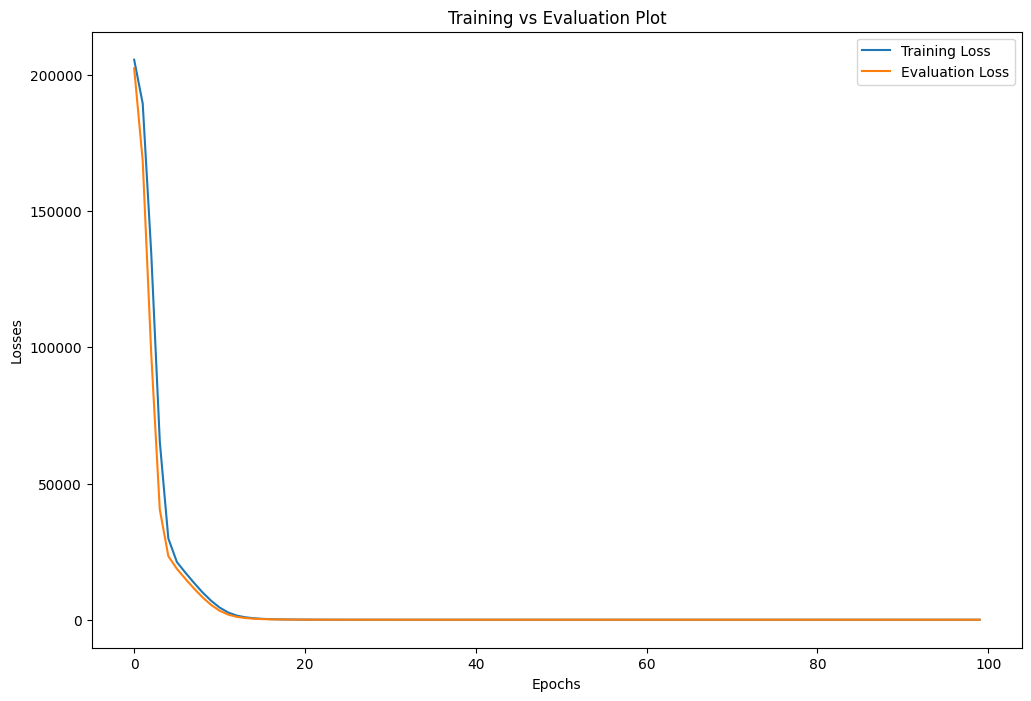

In [29]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training_Loss": train_losses,
    "Evaluation_Loss": val_losses,
})

plt.figure(figsize=(12,8))

plt.plot(loss_df["Training_Loss"], label="Training Loss")
plt.plot(loss_df["Evaluation_Loss"], label="Evaluation Loss")
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.title("Training vs Evaluation Plot")
plt.legend()



## Load the Best Model

In [30]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

## Evaluation

In [31]:
model.eval()

with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)
    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)
print("Training Mean Squared Error Loss: ", train_mse_loss.item())
print("Testing Mean Squared Error Loss: ", test_mse_loss.item())

Training Mean Squared Error Loss:  20.43276596069336
Testing Mean Squared Error Loss:  18.812828063964844


In [32]:
from sklearn.metrics import r2_score

r2_score(y_test, test_preds)

0.9342540154301647

In [34]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

new_df = pd.concat([predicted_df, actual_df], axis=1)

Text(0, 0.5, 'Actual Values')

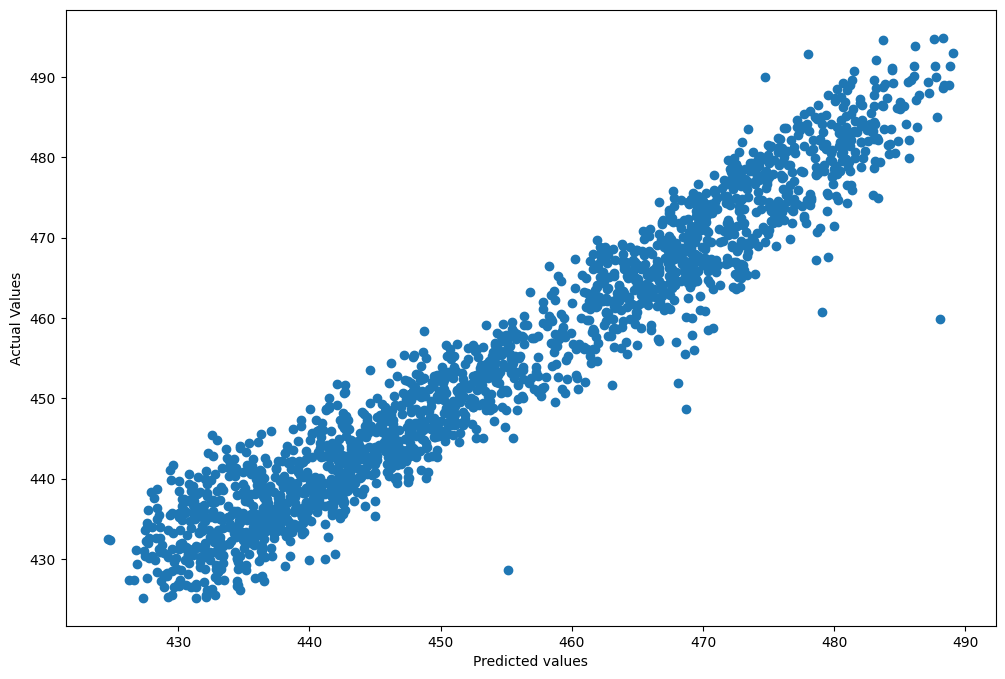

In [38]:
plt.figure(figsize=(12,8))
plt.scatter(new_df["Predicted Values"], new_df["Actual Values"])
plt.xlabel("Predicted values")
plt.ylabel("Actual Values")